# Initial Proposal Data Analysis

Chris Mulligan (12502987), George Lord (12243747), Max Zhalilo (12340701)

# Data Cleaning

## 1.1: Imports and paths

We are going to load our parquet files and compute the shared state as the latest first-date across the three raw parquets. Therefore, all datasets will overlap in day one.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
DATA_DIR = Path("Data")

_mins = {
    "spx": pl.scan_parquet(DATA_DIR / "spx_1s_2026-01-01_to_2026-02-26.parquet")
               .select(pl.col("time").min()).collect().item(),
    "vix": pl.scan_parquet(DATA_DIR / "vix_1s_2026-01-01_to_2026-02-26.parquet")
               .select(pl.col("time").min()).collect().item(),
    "spy": pl.scan_parquet(DATA_DIR / "spy_ohlcv_1s_rth.parquet")
               .select(pl.col("ts").min()).collect().item(),
}

START = str(max(_mins.values()).date())
END   = "2026-02-27"

for k, v in _mins.items():
    print(f"  {k} first timestamp : {v}")
print(f"\nSTART = {START}  (max of the three minimums)")
print(f"END   = {END}")

def rth_filter(col: str = "ts") -> pl.Expr:
    """Keep only regular trading hours: 9:30:00 – 16:00:00 ET.

    - after_open  : after 9:30 (exclusive of 9:00–9:29)
    - before_close: before 16:00, plus the 16:00:00 closing print only
      (hour <= 16 alone would let 16:01–16:59 through)
    - Avoids multiplying dt.hour() by 60 — dt.hour() is Int8 in this
      polars version, so values >= 128 would silently overflow.
    """
    hour   = pl.col(col).dt.hour()
    minute = pl.col(col).dt.minute()
    after_open   = (hour > 9) | ((hour == 9) & (minute >= 30))
    before_close = (hour < 16) | ((hour == 16) & (minute == 0))
    return after_open & before_close

  spx first timestamp : 2026-01-02 09:30:01-05:00
  vix first timestamp : 2026-01-02 03:15:01-05:00
  spy first timestamp : 2024-01-02 09:30:00-05:00

START = 2026-01-02  (max of the three minimums)
END   = 2026-02-27


## 1.2: SPX Series

We are taking the raw file `spx_1s_2026-01-01_to_2026-02-26.parquet` and cleaning. It began with shape (994,773, 2) with columns
* `price`
* `time`

We solved the following issues
* `time` renamed to `ts` for consistency across all datasets
* `price` renamed to `spx` so the column is self-describing after joins
* ~38 minutes of post-market data trimmed (raw data runs to 16:38:48)
* `date` string column added for easy join with Kalshi trade tables

In [ ]:
spx = (
    pl.read_parquet(DATA_DIR / "spx_1s_2026-01-01_to_2026-02-26.parquet")
    .rename({"time": "ts", "price": "spx"})
    .filter(rth_filter("ts"))
    .with_columns(
        pl.col("ts").dt.date().cast(pl.String).alias("date")
    )
    .select(["date", "ts", "spx"])
    .sort("ts")
)

assert spx.null_count().sum_horizontal().item() == 0, "Unexpected nulls in SPX"
assert spx["ts"].dt.hour().min() >= 9,  "SPX: timestamp before 9am"
assert spx["ts"].dt.hour().max() <= 16, "SPX: timestamp after 4pm"

print(f"SPX rows      : {spx.height:,}")
print(f"Date range    : {spx['ts'].min()}  ->  {spx['ts'].max()}")
print(f"Price range   : {spx['spx'].min():.2f}  -  {spx['spx'].max():.2f}")
print(f"Trading days  : {spx['date'].n_unique()}")
spx.head()

SPX rows      : 891,442
Date range    : 2026-01-02 09:30:01-05:00  ->  2026-02-26 16:00:59-05:00
Price range   : 6775.50  -  7002.28
Trading days  : 38


date,ts,spx
str,"datetime[μs, America/New_York]",f64
"""2026-01-02""",2026-01-02 09:30:01 EST,6878.11
"""2026-01-02""",2026-01-02 09:30:02 EST,6880.86
"""2026-01-02""",2026-01-02 09:30:03 EST,6881.53
"""2026-01-02""",2026-01-02 09:30:04 EST,6882.16
"""2026-01-02""",2026-01-02 09:30:05 EST,6881.47


## 1.3: VIX Series

We are taking the raw file `vix_1s_2026-01-01_to_2026-02-26.parquet` and cleaning. It began with shape (1,837,840, 2) with columns
* Price
* Time

We solved the following issues
* `time` renamed to `ts`, `price` renamed to `vix`
* Extended hours stripped: raw data starts at 03:15 AM (VIX calculates continuously from SPX options; we keep only RTH to align with SPX/SPY)
* `date` string column added

In [ ]:
vix = (
    pl.read_parquet(DATA_DIR / "vix_1s_2026-01-01_to_2026-02-26.parquet")
    .rename({"time": "ts", "price": "vix"})
    .filter(rth_filter("ts"))
    .with_columns(
        pl.col("ts").dt.date().cast(pl.String).alias("date")
    )
    .select(["date", "ts", "vix"])
    .sort("ts")
)

assert vix.null_count().sum_horizontal().item() == 0, "Unexpected nulls in VIX"
assert vix["ts"].dt.hour().min() >= 9,  "VIX: timestamp before 9am"
assert vix["ts"].dt.hour().max() <= 16, "VIX: timestamp after 4pm"

print(f"VIX rows      : {vix.height:,}")
print(f"Date range    : {vix['ts'].min()}  ->  {vix['ts'].max()}")
print(f"VIX range     : {vix['vix'].min():.2f}  -  {vix['vix'].max():.2f}")
print(f"Trading days  : {vix['date'].n_unique()}")
vix.head()

VIX rows      : 905,884
Date range    : 2026-01-02 09:30:00-05:00  ->  2026-02-26 16:00:59-05:00
VIX range     : 14.43  -  23.10
Trading days  : 40


date,ts,vix
str,"datetime[μs, America/New_York]",f64
"""2026-01-02""",2026-01-02 09:30:00 EST,14.74
"""2026-01-02""",2026-01-02 09:30:01 EST,14.74
"""2026-01-02""",2026-01-02 09:30:02 EST,14.74
"""2026-01-02""",2026-01-02 09:30:03 EST,14.74
"""2026-01-02""",2026-01-02 09:30:04 EST,14.74


## 1.4: SPY Series

We are taking the raw file `spy_ohlcv_1s_rth.parquet` and cleaning. It began with shape (9,119,728, 7) with columns
* ts
* open
* high
* low
* close
* volume
* symbol

We solved the following issues
* Timestamp downcast from nanoseconds -> microseconds (matches SPX/VIX and the Kalshi trade tables; ns precision is meaningless for 1s bars)
* `symbol` column dropped (always `SPY`, wastes memory at 9M rows)
* Date range trimmed to 2026 to match SPX/VIX window (raw file covers 2024-01-02 to 2026-02-25)
* `date` string column added

In [ ]:
spy = (
    pl.read_parquet(DATA_DIR / "spy_ohlcv_1s_rth.parquet")
    .drop("symbol")
    .with_columns(
        pl.col("ts").dt.cast_time_unit("us"),
        pl.col("ts").dt.date().cast(pl.String).alias("date"),
    )
    .filter(pl.col("date").is_between(pl.lit(START), pl.lit(END)))
    .select(["date", "ts", "open", "high", "low", "close", "volume"])
    .sort("ts")
)

assert spy.null_count().sum_horizontal().item() == 0, "Unexpected nulls in SPY"
assert spy["volume"].min() > 0, "SPY: zero-volume bar found"

print(f"SPY rows      : {spy.height:,}")
print(f"Date range    : {spy['ts'].min()}  ->  {spy['ts'].max()}")
print(f"Close range   : {spy['close'].min():.2f}  -  {spy['close'].max():.2f}")
print(f"Trading days  : {spy['date'].n_unique()}")
spy.head()

SPY rows      : 767,574
Date range    : 2026-01-02 09:30:00-05:00  ->  2026-02-25 15:59:59-05:00
Close range   : 675.79  -  697.82
Trading days  : 37


date,ts,open,high,low,close,volume
str,"datetime[μs, America/New_York]",f64,f64,f64,f64,i64
"""2026-01-02""",2026-01-02 09:30:00 EST,685.71,685.73,685.49,685.52,30504
"""2026-01-02""",2026-01-02 09:30:01 EST,685.52,685.57,685.49,685.5,13034
"""2026-01-02""",2026-01-02 09:30:02 EST,685.5,685.58,685.48,685.48,40579
"""2026-01-02""",2026-01-02 09:30:03 EST,685.48,685.48,685.38,685.44,11990
"""2026-01-02""",2026-01-02 09:30:04 EST,685.45,685.48,685.43,685.44,12449


## 1.5: Save Cleaned Files

We are writing one parquet per asset into Data/ alongside the raw files. We will load these `_clean` files everywhere else in the project

In [ ]:
for name, df in [("spx", spx), ("vix", vix), ("spy", spy)]:
    path = DATA_DIR / f"{name}_clean.parquet"
    df.write_parquet(path, compression="zstd", compression_level=3)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved {path.name:30s}  {df.height:>9,} rows  {size_mb:.1f} MB")

Saved spx_clean.parquet                 891,442 rows  4.4 MB
Saved vix_clean.parquet                 905,884 rows  2.7 MB
Saved spy_clean.parquet                 767,574 rows  7.4 MB


## 1.6: KXINX Contracts

We take the folder of parquetes in the KXINX contracts, combine, and clean. The KXINX contract is Kalshi's daily SPX close RANGE (bracket) market. Each contract pays $1 if SPX closes within a specific 25-point bracket. There are 208 files totally about 14k trades. 

The ticker can be interpreted as follows:
* Format: KXINX - {YYMONDD} H1600 - B{midpoint}
* Example: KXINX-26FEB02H1600-B6912
* Series: KXINX  (SPX close range)
* Expiry: Feb 2, 2026 at 16:00 ET  (same-day settlement at market close)
* B6912: bracket midpoint label; floor = (6912 // 25) * 25 = 6900 → contract pays if SPX closes in [6900, 6924.9999]

For each day, 6 contracts were selected (3 above + 3 below the SPX close):
* side_of_close = "above"  → bracket is entirely above the actual SPX close
* side_of_close = "below"  → bracket is entirely below the actual SPX close

We solved the following issues: 
* Consolidate all 208 per-ticker parquet files into one DataFrame
* Convert ts from UTC → America/New_York (consistent with SPX/VIX/SPY)
* Parse bracket floor/cap from ticker suffix  (-B{midpoint})
* Derive contract_desc: human-readable label for each unique contract
* Validate: price ∈ [0, 1], quantity > 0, no nulls in key columns

In [ ]:
kxinx = (
    pl.read_parquet("Data-Exploration/parquet_exports/1_2/*.parquet")
    .with_columns(
        # Convert trade timestamps from UTC to Eastern time
        pl.col("ts").dt.convert_time_zone("America/New_York"),

        # Recover bracket floor from the ticker suffix "-B{midpoint}":
        #   midpoint (e.g. 6912) is the centre of a 25-pt bracket.
        #   floor = (midpoint // 25) * 25   →   6912 // 25 * 25 = 6900
        (
            pl.col("ticker").str.extract(r"-B(\d+)$", 1)
              .cast(pl.Int32) // 25 * 25
        ).cast(pl.Float64).alias("bracket_floor"),
    )
    .with_columns(
        # cap = floor + 25  (Kalshi stores it as floor + 24.9999, same thing)
        (pl.col("bracket_floor") + 25.0).alias("bracket_cap"),

        # Human-readable contract label
        pl.concat_str([
            pl.lit("KXINX: SPX in ["),
            pl.col("bracket_floor").cast(pl.String),
            pl.lit(", "),
            (pl.col("bracket_floor") + 25.0).cast(pl.String),
            pl.lit(")  exp "),
            pl.col("date"),
        ]).alias("contract_desc"),
    )
    .select([
        "date", "ticker", "contract_desc", "bracket_floor", "bracket_cap",
        "side_of_close", "ts", "price", "quantity",
        "direction", "liquidity_event",
    ])
    .sort(["date", "ticker", "ts"])
)

# Validate
assert kxinx.filter((pl.col("price") < 0) | (pl.col("price") > 1)).height == 0, \
    "KXINX: price outside [0, 1]"
assert kxinx.filter(pl.col("quantity") <= 0).height == 0, \
    "KXINX: non-positive quantity"
assert kxinx.select(["date", "ticker", "ts", "price", "quantity"]) \
    .null_count().sum_horizontal().item() == 0, "KXINX: unexpected nulls"

print(f"KXINX rows          : {kxinx.height:,}")
print(f"Unique contracts    : {kxinx['ticker'].n_unique()}")
print(f"Trading days        : {kxinx['date'].n_unique()}")
print(f"Bracket floor range : {kxinx['bracket_floor'].min():.0f}  –  {kxinx['bracket_floor'].max():.0f}")
print(f"Price range         : {kxinx['price'].min():.2f}  –  {kxinx['price'].max():.2f}")
print(f"\nSample contract descriptions:")
print(kxinx.select(["ticker", "contract_desc", "side_of_close"]).unique(subset=["ticker"]).sort("ticker").head(6))
kxinx.head()


KXINX rows          : 13,617
Unique contracts    : 208
Trading days        : 38
Bracket floor range : 6725  –  7050
Price range         : 0.01  –  0.99

Sample contract descriptions:
shape: (6, 3)
┌──────────────────────────┬─────────────────────────────────┬───────────────┐
│ ticker                   ┆ contract_desc                   ┆ side_of_close │
│ ---                      ┆ ---                             ┆ ---           │
│ str                      ┆ str                             ┆ str           │
╞══════════════════════════╪═════════════════════════════════╪═══════════════╡
│ KXINX-26FEB02H1600-B6912 ┆ KXINX: SPX in [6900.0, 6925.0)… ┆ below         │
│ KXINX-26FEB02H1600-B6937 ┆ KXINX: SPX in [6925.0, 6950.0)… ┆ below         │
│ KXINX-26FEB02H1600-B6962 ┆ KXINX: SPX in [6950.0, 6975.0)… ┆ below         │
│ KXINX-26FEB02H1600-B7012 ┆ KXINX: SPX in [7000.0, 7025.0)… ┆ above         │
│ KXINX-26FEB03H1600-B6837 ┆ KXINX: SPX in [6825.0, 6850.0)… ┆ below         │
│ KXINX-26FEB

date,ticker,contract_desc,bracket_floor,bracket_cap,side_of_close,ts,price,quantity,direction,liquidity_event
str,str,str,f64,f64,str,"datetime[μs, America/New_York]",f64,f64,str,str
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 19:27:55.835333 EST,0.41,15.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 21:46:31.683290 EST,0.41,23.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 22:34:01.204800 EST,0.06,4.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 23:14:32.476601 EST,0.06,46.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-02 00:39:11.429760 EST,0.06,50.0,"""no_taker""","""hit_bid"""


## 1.7: KXINXU Contracts

We take the folder of parquetes in the KXINXU contracts, combine, and clean. The KXINXU contract is Kalshi's daily SPX close DIRECTIONAL (unbounded-up) market. Each contract pays $1 if SPX closes ABOVE a fixed threshold on expiry day. These are one-sides - no upper cap. There are 215 files totally about 43k trades. 

The ticker can be interpreted as follows:
* Format: KXINXU - {YYMONDD} H1600 - T{threshold}
* Example: KXINXU-26JAN02H1600-T6799.9999
* Series: KXINXU  (SPX close above threshold)
* Expiry: Jan 2, 2026 at 16:00 ET  (same-day settlement at market close)
* Threshold: 6799.9999  → contract pays if SPX closes above 6799.9999

For each day the same 3-above / 3-below selection was used as in 1.2:
* side_of_close = "above"  → threshold is above that day's actual SPX close
* side_of_close = "below"  → threshold is below that day's actual SPX close

We solved the following issues: 
* Consolidate all 215 per-ticker parquet files into one DataFrame
* Convert ts from UTC → America/New_York (consistent with SPX/VIX/SPY)
* Parse threshold from ticker suffix  (-T{threshold})
* Derive contract_desc: human-readable label for each unique contract
* Validate: price ∈ [0, 1], quantity > 0, no nulls in key columns

In [ ]:
kxinxu = (
    pl.read_parquet("Data-Exploration/parquet_exports/1_4/*.parquet")
    .with_columns(
        # Convert trade timestamps from UTC to Eastern time
        pl.col("ts").dt.convert_time_zone("America/New_York"),

        # Extract the threshold value from the ticker suffix "-T{threshold}"
        # Example: KXINXU-26JAN02H1600-T6799.9999  →  threshold = 6799.9999
        pl.col("ticker")
          .str.extract(r"-T([\d.]+)$", 1)
          .cast(pl.Float64)
          .alias("threshold"),
    )
    .with_columns(
        # Human-readable contract label
        pl.concat_str([
            pl.lit("KXINXU: SPX > "),
            pl.col("threshold").cast(pl.String),
            pl.lit("  exp "),
            pl.col("date"),
        ]).alias("contract_desc")
    )
    .select([
        "date", "ticker", "contract_desc", "threshold",
        "side_of_close", "ts", "price", "quantity",
        "direction", "liquidity_event",
    ])
    .sort(["date", "ticker", "ts"])
)

# Validate
assert kxinxu.filter((pl.col("price") < 0) | (pl.col("price") > 1)).height == 0, \
    "KXINXU: price outside [0, 1]"
assert kxinxu.filter(pl.col("quantity") <= 0).height == 0, \
    "KXINXU: non-positive quantity"
assert kxinxu.select(["date", "ticker", "ts", "price", "quantity"]) \
    .null_count().sum_horizontal().item() == 0, "KXINXU: unexpected nulls"

print(f"KXINXU rows         : {kxinxu.height:,}")
print(f"Unique contracts    : {kxinxu['ticker'].n_unique()}")
print(f"Trading days        : {kxinxu['date'].n_unique()}")
print(f"Threshold range     : {kxinxu['threshold'].min():.2f}  –  {kxinxu['threshold'].max():.2f}")
print(f"Price range         : {kxinxu['price'].min():.2f}  –  {kxinxu['price'].max():.2f}")
print(f"\nSample contract descriptions:")
print(kxinxu.select(["ticker", "contract_desc", "side_of_close"]).unique(subset=["ticker"]).sort("ticker").head(6))
kxinxu.head()


KXINXU rows         : 43,188
Unique contracts    : 215
Trading days        : 37
Threshold range     : 6725.00  –  7050.00
Price range         : 0.01  –  0.99

Sample contract descriptions:
shape: (6, 3)
┌────────────────────────────────┬─────────────────────────────────┬───────────────┐
│ ticker                         ┆ contract_desc                   ┆ side_of_close │
│ ---                            ┆ ---                             ┆ ---           │
│ str                            ┆ str                             ┆ str           │
╞════════════════════════════════╪═════════════════════════════════╪═══════════════╡
│ KXINXU-26FEB02H1600-T6924.9999 ┆ KXINXU: SPX > 6924.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6949.9999 ┆ KXINXU: SPX > 6949.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6974.9999 ┆ KXINXU: SPX > 6974.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6999.9999 ┆ KXINXU: SPX > 6999.9999  exp 2… ┆ above         │
│ KXINXU-26FEB02H1600-T7024.9999

date,ticker,contract_desc,threshold,side_of_close,ts,price,quantity,direction,liquidity_event
str,str,str,f64,str,"datetime[μs, America/New_York]",f64,f64,str,str
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 08:07:01.212740 EST,0.96,30.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 10:27:44.515689 EST,0.87,100.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:04:06.759015 EST,0.86,1.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:05:54.618135 EST,0.88,100.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:07:38.803017 EST,0.84,1.0,"""yes_taker""","""lift_offer"""


## 1.8: Save Cleaned Kalshi Files

We write both consolidated Kalshi tables into Data/ so we can use them for the rest of the project

In [ ]:
for name, df in [("kalshi_kxinx_clean", kxinx), ("kalshi_kxinxu_clean", kxinxu)]:
    path = Path("Data") / f"{name}.parquet"
    df.write_parquet(path, compression="zstd", compression_level=3)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved {path.name:35s}  {df.height:>7,} rows  {size_mb:.1f} MB")


Saved kalshi_kxinx_clean.parquet            13,617 rows  0.1 MB
Saved kalshi_kxinxu_clean.parquet           43,188 rows  0.3 MB


# Data Analysis

## 2.1: Load Cleaned Parquets and Compute Daily Aggregates

We derive the daily aggregates for initial analysis, although our strategy will rely on a 1s scale.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("Data")

spx = pl.read_parquet(DATA_DIR / "spx_clean.parquet")
vix = pl.read_parquet(DATA_DIR / "vix_clean.parquet")
spy = pl.read_parquet(DATA_DIR / "spy_clean.parquet")

# --- daily aggregates ---------------------------------------------------

# SPX: first tick = open, last tick = close (forward-filled 1s series)
spx_daily = (
    spx.sort("ts")
    .group_by("date")
    .agg(
        pl.col("spx").first().alias("open"),
        pl.col("spx").last().alias("close"),
        pl.col("spx").max().alias("high"),
        pl.col("spx").min().alias("low"),
    )
    .sort("date")
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).mul(100).alias("ret_pct")
    )
)

# VIX: last tick of the day = closing level
vix_daily = (
    vix.sort("ts")
    .group_by("date")
    .agg(pl.col("vix").last().alias("close"))
    .sort("date")
)

# SPY: first open, last close, session high/low, total volume
spy_daily = (
    spy.sort("ts")
    .group_by("date")
    .agg(
        pl.col("open").first().alias("open"),
        pl.col("close").last().alias("close"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort("date")
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).mul(100).alias("ret_pct")
    )
)

print(f"SPX daily rows : {spx_daily.height}  |  return mean: {spx_daily['ret_pct'].drop_nulls().mean():.3f}%  std: {spx_daily['ret_pct'].drop_nulls().std():.3f}%")
print(f"VIX daily rows : {vix_daily.height}  |  avg close: {vix_daily['close'].mean():.2f}")
print(f"SPY daily rows : {spy_daily.height}  |  avg volume: {spy_daily['volume'].mean():,.0f}")


SPX daily rows : 38  |  return mean: 0.023%  std: 0.767%
VIX daily rows : 40  |  avg close: 17.63
SPY daily rows : 37  |  avg volume: 18,916,099


## 2.2: Graph 1: SPX Close Price and VIX Level

We vertically stack panels sharing an x-axis. The inverse relationship between SPX and VIX is the central dynamic in pricing Kalshi binary contracts: rising VIX widens the probable range of SPX outcomes and inflates the price of out-of-money brackets. 

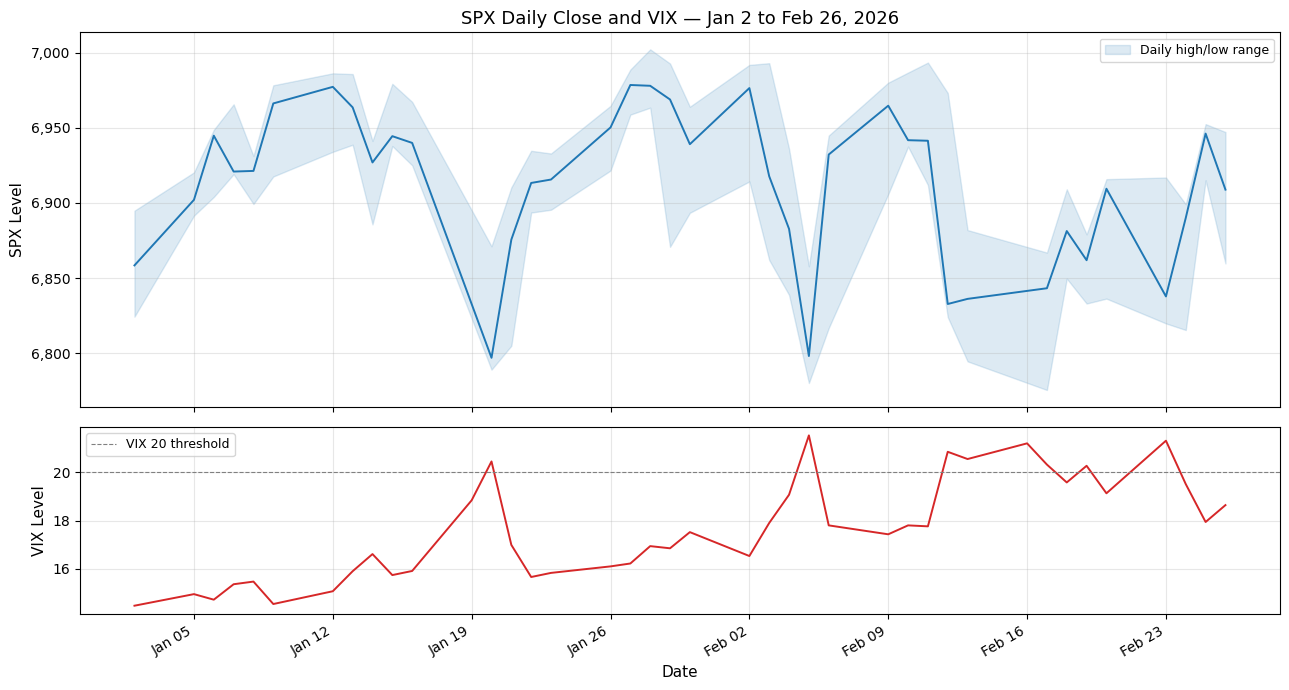

In [ ]:
spx_pd = spx_daily.to_pandas()
vix_pd = vix_daily.to_pandas()
spx_pd["date"] = pd.to_datetime(spx_pd["date"])
vix_pd["date"] = pd.to_datetime(vix_pd["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# --- SPX panel ---
ax1.plot(spx_pd["date"], spx_pd["close"], color="#1f77b4", linewidth=1.4)
ax1.fill_between(spx_pd["date"], spx_pd["low"], spx_pd["high"],
                 alpha=0.15, color="#1f77b4", label="Daily high/low range")
ax1.set_ylabel("SPX Level", fontsize=11)
ax1.set_title("SPX Daily Close and VIX — Jan 2 to Feb 26, 2026", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- VIX panel ---
ax2.plot(vix_pd["date"], vix_pd["close"], color="#d62728", linewidth=1.4)
ax2.axhline(20, color="grey", linestyle="--", linewidth=0.8, label="VIX 20 threshold")
ax2.set_ylabel("VIX Level", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


## 2.3: Graph 2: SPX Daily Return Distribution

The distribution of daily SPX returns determines how often the index crosses any given strike level — directly setting the fair value of Kalshi's range and directional contracts. A normal overlay is included to show how much the actual distribution deviates from the Gaussian assumption.

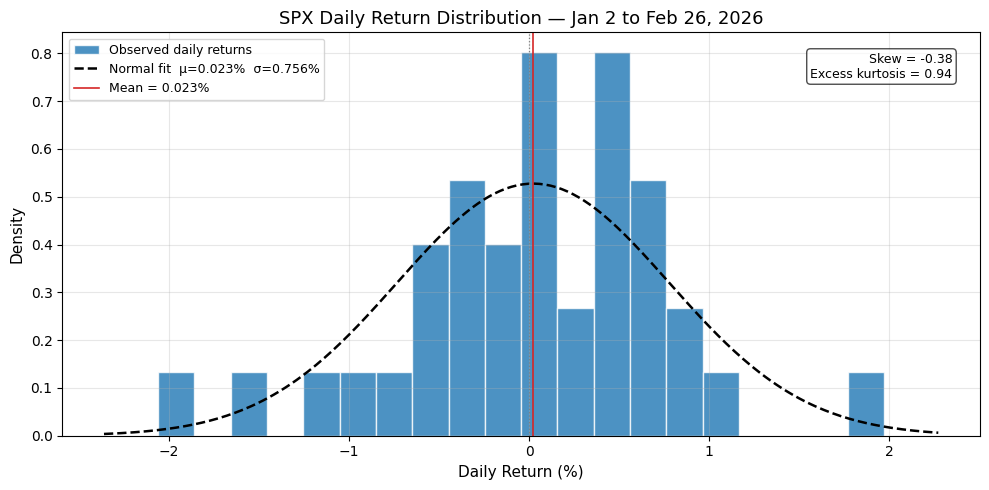

In [ ]:
returns = spx_daily["ret_pct"].drop_nulls().to_numpy()
mu, sigma = returns.mean(), returns.std()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(returns, bins=20, color="#1f77b4", edgecolor="white",
        alpha=0.8, density=True, label="Observed daily returns")

# Normal distribution overlay
x = np.linspace(returns.min() - 0.3, returns.max() + 0.3, 300)
ax.plot(x, (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2),
        color="black", linewidth=1.8, linestyle="--", label=f"Normal fit  μ={mu:.3f}%  σ={sigma:.3f}%")

ax.axvline(0, color="grey", linewidth=0.9, linestyle=":")
ax.axvline(mu, color="#d62728", linewidth=1.2, linestyle="-",
           label=f"Mean = {mu:.3f}%")

ax.set_xlabel("Daily Return (%)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("SPX Daily Return Distribution — Jan 2 to Feb 26, 2026", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Annotate skew and kurtosis
from scipy import stats as sp_stats
sk = sp_stats.skew(returns)
ku = sp_stats.kurtosis(returns)
ax.text(0.97, 0.95, f"Skew = {sk:.2f}\nExcess kurtosis = {ku:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()


## 2.4: Graph 3: SPX Daily Return vs Opening VIX Level

Each dot is one trading day. Higher VIX at the open signals wider expected moves — Kalshi contracts priced before 9:30 must anticipate this. The scatter shows whether realised SPX swings actually widen with VIX, and whether VIX predicts the direction of the move.

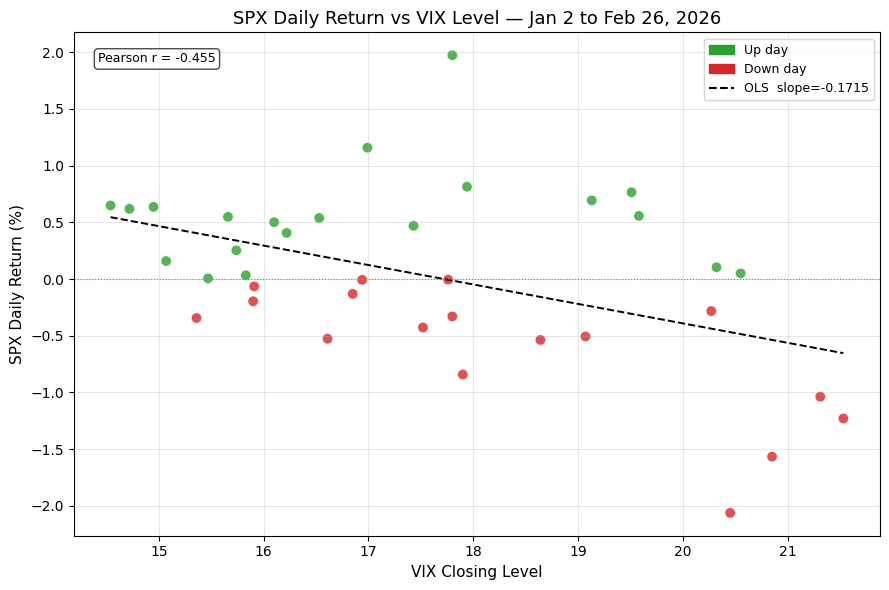

In [ ]:
joined = (
    spx_daily.select(["date", "ret_pct"])
    .join(vix_daily.rename({"close": "vix_close"}), on="date", how="inner")
    .drop_nulls()
    .to_pandas()
)

colors = ["#2ca02c" if r > 0 else "#d62728" for r in joined["ret_pct"]]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(joined["vix_close"], joined["ret_pct"],
           c=colors, s=55, alpha=0.8, edgecolors="white", linewidths=0.4)

# OLS regression line
m, b = np.polyfit(joined["vix_close"], joined["ret_pct"], 1)
xr = np.linspace(joined["vix_close"].min(), joined["vix_close"].max(), 100)
ax.plot(xr, m * xr + b, color="black", linewidth=1.4, linestyle="--",
        label=f"OLS  slope={m:.4f}  intercept={b:.3f}")

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")

# Dummy patches for legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ca02c", label="Up day"),
    Patch(color="#d62728", label="Down day"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"OLS  slope={m:.4f}")
], fontsize=9)

ax.set_xlabel("VIX Closing Level", fontsize=11)
ax.set_ylabel("SPX Daily Return (%)", fontsize=11)
ax.set_title("SPX Daily Return vs VIX Level — Jan 2 to Feb 26, 2026", fontsize=13)
ax.grid(alpha=0.3)

corr = joined["vix_close"].corr(joined["ret_pct"])
ax.text(0.03, 0.96, f"Pearson r = {corr:.3f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()


## 2.5: Graph 4: Average Intraday SPX Price Path (Normalized to Open)

For each trading day, every second's price is expressed as a % deviation from that day's 9:30 open. Averaging across all 38 days reveals a systematic intraday drift pattern. This matters for Kalshi contracts because they settle at the 4 PM close: if the index systematically drifts in a direction during the day, the morning market price of a contract should embed that expected drift.


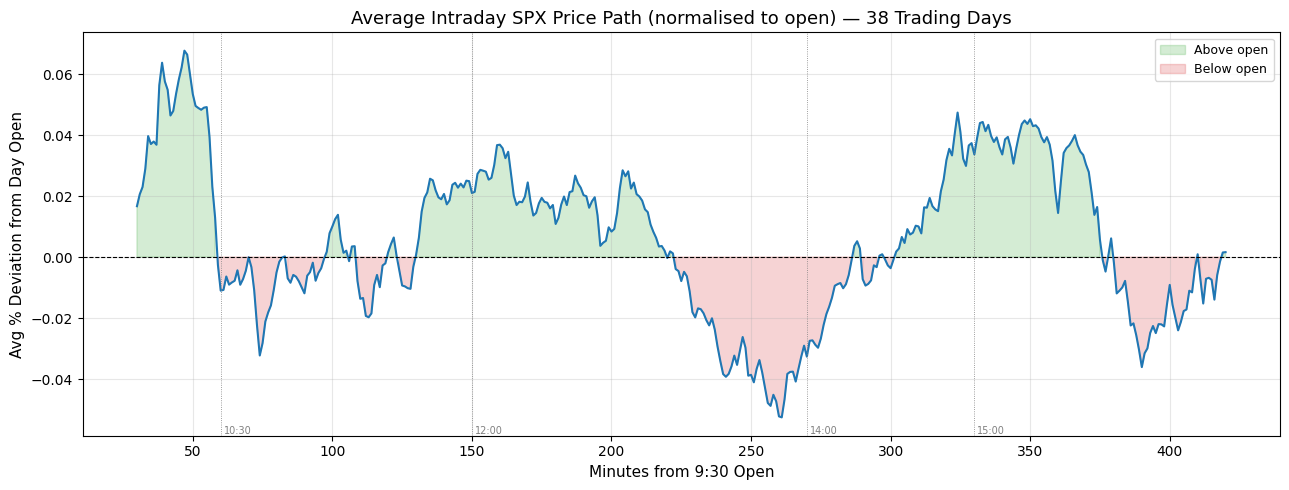

In [ ]:
# Normalise each second's price to that day's 9:30 open
spx_norm = (
    spx.sort("ts")
    .with_columns(
        pl.col("spx").first().over("date").alias("day_open"),
        pl.col("ts").dt.hour().cast(pl.Int16).alias("hour"),
        pl.col("ts").dt.minute().cast(pl.Int16).alias("minute"),
        pl.col("ts").dt.second().cast(pl.Int16).alias("second"),
    )
    .with_columns(
        ((pl.col("spx") / pl.col("day_open") - 1) * 100).alias("norm_pct"),
        (
            (pl.col("hour") - 9) * 3600
            + pl.col("minute") * 60
            + pl.col("second")
        ).alias("sec_from_open"),
    )
)

# Average normalised price by second-from-open, then resample to 1-minute
# buckets for a readable plot
intraday = (
    spx_norm
    .group_by("sec_from_open")
    .agg(pl.col("norm_pct").mean())
    .sort("sec_from_open")
    .with_columns(
        (pl.col("sec_from_open") // 60).alias("min_from_open")
    )
    .group_by("min_from_open")
    .agg(pl.col("norm_pct").mean())
    .sort("min_from_open")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(intraday["min_from_open"], intraday["norm_pct"],
        color="#1f77b4", linewidth=1.5)
ax.fill_between(intraday["min_from_open"], intraday["norm_pct"], 0,
                where=(intraday["norm_pct"] >= 0),
                alpha=0.2, color="#2ca02c", label="Above open")
ax.fill_between(intraday["min_from_open"], intraday["norm_pct"], 0,
                where=(intraday["norm_pct"] < 0),
                alpha=0.2, color="#d62728", label="Below open")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Label key times
for label, minute in [("10:30", 60), ("12:00", 150), ("14:00", 270), ("15:00", 330)]:
    ax.axvline(minute, color="grey", linewidth=0.6, linestyle=":")
    ax.text(minute + 1, ax.get_ylim()[0], label, fontsize=7, color="grey", va="bottom")

ax.set_xlabel("Minutes from 9:30 Open", fontsize=11)
ax.set_ylabel("Avg % Deviation from Day Open", fontsize=11)
ax.set_title("Average Intraday SPX Price Path (normalised to open) — 38 Trading Days", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2.6: Graph 5: SPY Daily Close Price and Total Session Volume

SPY is the most liquid equity ETF and tracks SPX at ~1/10 scale. Volume is unavailable for the SPX index itself, so SPY volume serves as the best proxy for S&P 500 market activity. Heavy-volume days tend to produce larger SPX moves, widening the distribution of outcomes that Kalshi bracket contracts must price.

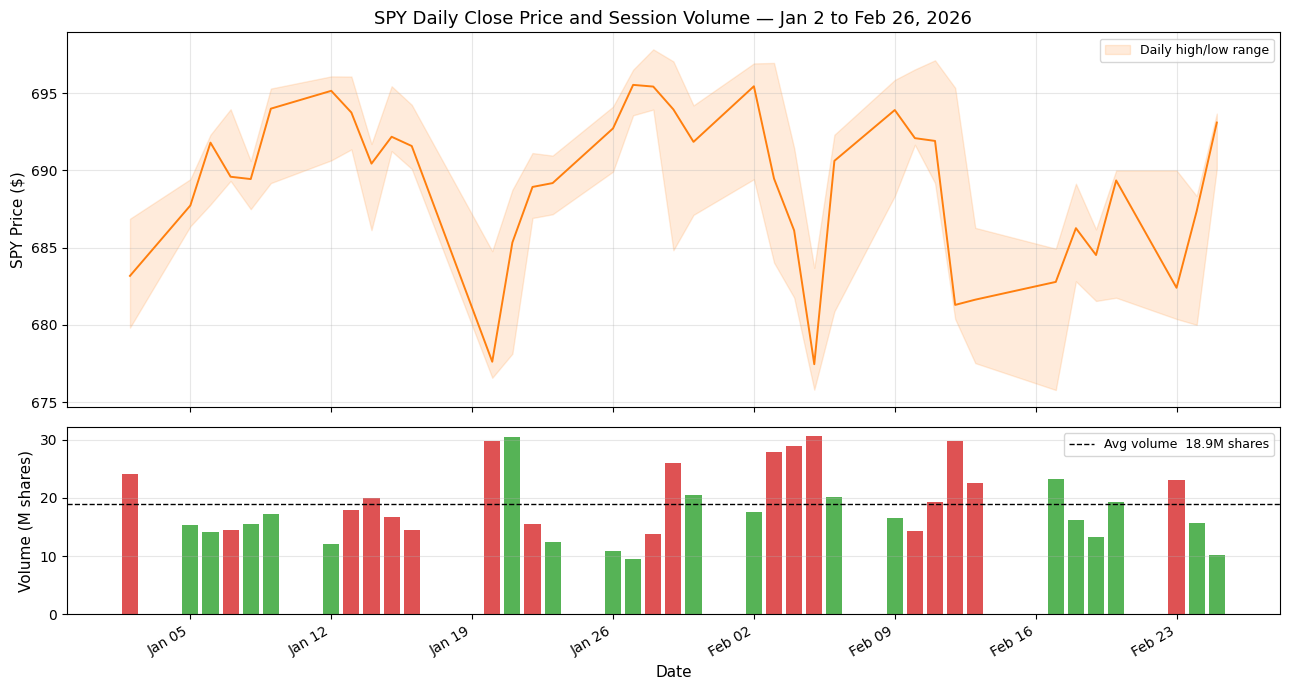

In [ ]:
spy_pd = spy_daily.to_pandas()
spy_pd["date"] = pd.to_datetime(spy_pd["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# --- SPY price panel ---
ax1.plot(spy_pd["date"], spy_pd["close"], color="#ff7f0e", linewidth=1.4)
ax1.fill_between(spy_pd["date"], spy_pd["low"], spy_pd["high"],
                 alpha=0.15, color="#ff7f0e", label="Daily high/low range")
ax1.set_ylabel("SPY Price ($)", fontsize=11)
ax1.set_title("SPY Daily Close Price and Session Volume — Jan 2 to Feb 26, 2026", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Colour bars by up/down day
bar_colors = ["#2ca02c" if c >= o else "#d62728"
              for c, o in zip(spy_pd["close"], spy_pd["open"])]

# --- Volume panel ---
ax2.bar(spy_pd["date"], spy_pd["volume"] / 1e6, color=bar_colors,
        alpha=0.8, width=0.8)
avg_vol = spy_pd["volume"].mean() / 1e6
ax2.axhline(avg_vol, color="black", linewidth=1.0, linestyle="--",
            label=f"Avg volume  {avg_vol:.1f}M shares")
ax2.set_ylabel("Volume (M shares)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


## 2.7: Graph 6: SPY Average Intraday Volume Profile

The classic U-shaped intraday volume curve (heavy at open and close, thin at midday). This is directly relevant to the project: Kalshi contracts settle at the 4 PM SPX close, a period of very high SPY volume. High end-of-day liquidity means SPX prices are harder to manipulate near settlement, lending credibility to the contracts' settlement prices.

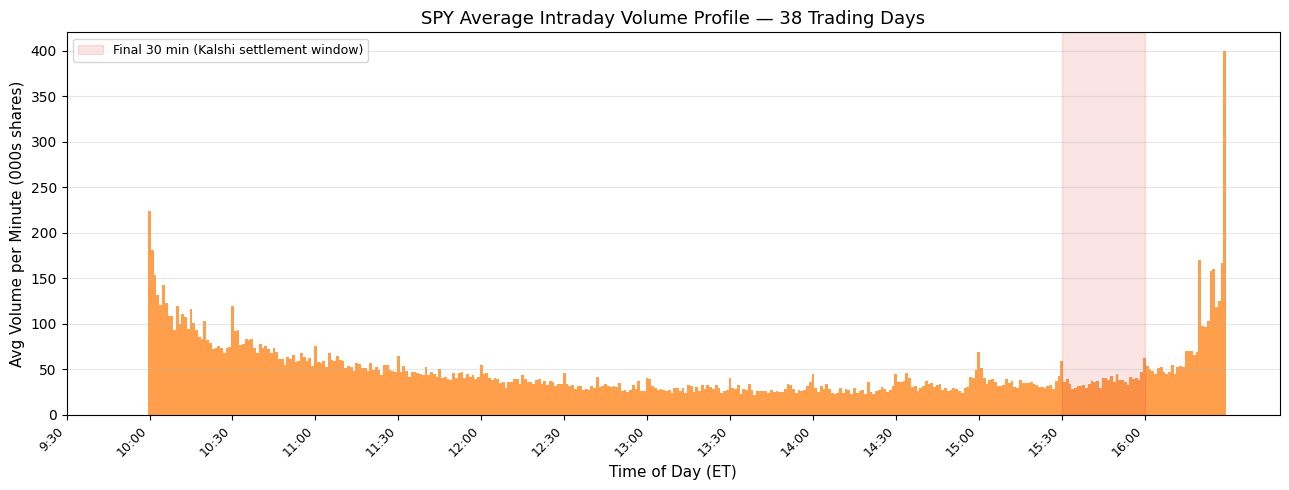

In [ ]:
spy_intraday_vol = (
    spy
    .with_columns(
        pl.col("ts").dt.hour().cast(pl.Int16).alias("hour"),
        pl.col("ts").dt.minute().cast(pl.Int16).alias("minute"),
    )
    .with_columns(
        (
            (pl.col("hour") - 9) * 60 + pl.col("minute")
        ).alias("min_from_open")
    )
    .group_by(["date", "min_from_open"])
    .agg(pl.col("volume").sum().alias("volume"))
    .group_by("min_from_open")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("min_from_open")
    .to_pandas()
)

# x-axis labels: convert minute offset back to clock time
def min_to_label(m):
    total = 9 * 60 + 30 + m
    return f"{total // 60}:{total % 60:02d}"

tick_positions = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390]
tick_labels = [min_to_label(m) for m in tick_positions]

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(spy_intraday_vol["min_from_open"],
       spy_intraday_vol["avg_volume"] / 1e3,
       color="#ff7f0e", alpha=0.75, width=1.0)

# Highlight the last 30 minutes (settlement window for Kalshi contracts)
ax.axvspan(360, 390, alpha=0.12, color="#d62728", label="Final 30 min (Kalshi settlement window)")
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Time of Day (ET)", fontsize=11)
ax.set_ylabel("Avg Volume per Minute (000s shares)", fontsize=11)
ax.set_title("SPY Average Intraday Volume Profile — 38 Trading Days", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


# Kalshi Contract Analysis

We load the cleaned Kalshi data and compute the daily aggregates as above.

In [ ]:
DATA_DIR = Path("Data")

kxinx  = pl.read_parquet(DATA_DIR / "kalshi_kxinx_clean.parquet")
kxinxu = pl.read_parquet(DATA_DIR / "kalshi_kxinxu_clean.parquet")

# SPX daily close — needed to compute distance from strike to actual close
spx_close_daily = (
    pl.read_parquet(DATA_DIR / "spx_clean.parquet")
    .sort("ts")
    .group_by("date")
    .agg(pl.col("spx").last().alias("spx_close"))
    .sort("date")
)

# Daily trade counts
kxinx_daily  = kxinx.group_by("date").agg(pl.len().alias("trades")).sort("date")
kxinxu_daily = kxinxu.group_by("date").agg(pl.len().alias("trades")).sort("date")

# Per-contract daily VWAP for KXINX, joined with SPX close
kxinx_vwap = (
    kxinx
    .group_by(["date", "ticker", "bracket_floor", "bracket_cap", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        # Distance = index points between SPX close and the nearest bracket edge
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))   # above: floor is nearest edge
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap")) # below: cap is nearest edge
          .alias("distance_from_close")
    )
    .sort(["date", "ticker"])
)

# Per-contract daily VWAP for KXINXU, joined with SPX close
kxinxu_vwap = (
    kxinxu
    .group_by(["date", "ticker", "threshold", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("threshold") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("threshold"))
          .alias("distance_from_close")
    )
    .sort(["date", "ticker"])
)

print(f"KXINX  — {kxinx.height:,} trades | {kxinx['date'].n_unique()} days | {kxinx['ticker'].n_unique()} contracts")
print(f"KXINXU — {kxinxu.height:,} trades | {kxinxu['date'].n_unique()} days | {kxinxu['ticker'].n_unique()} contracts")


KXINX  — 13,617 trades | 38 days | 208 contracts
KXINXU — 43,188 trades | 37 days | 215 contracts


## 3.2: Graph 7: Daily Kalshi contract trade volume over the study period

Side-by-side bars for KXINX (range bracket) and KXINXU (directional) show how trading activity evolved day-by-day.  KXINXU typically has more trades because it offers more individual strike levels than the 25-pt bracket grid.

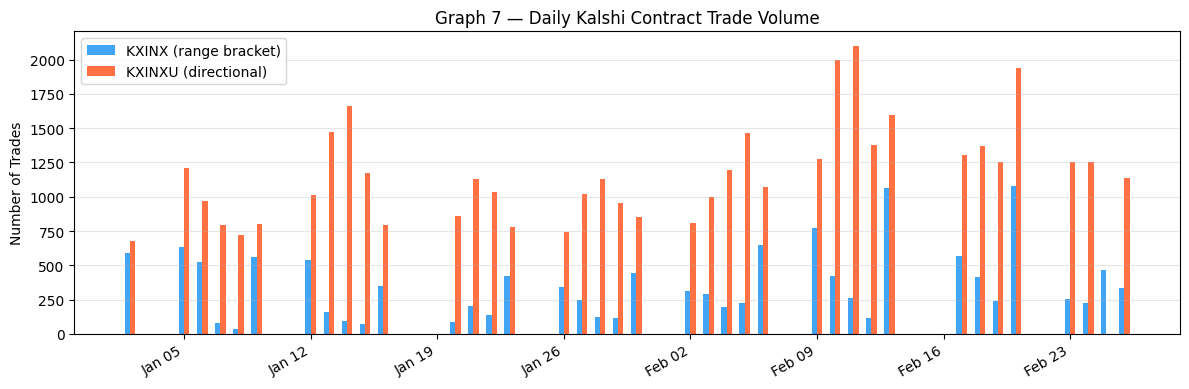

In [ ]:
kxinx_pd  = kxinx_daily.to_pandas()
kxinxu_pd = kxinxu_daily.to_pandas()
kxinx_pd["date"]  = pd.to_datetime(kxinx_pd["date"])
kxinxu_pd["date"] = pd.to_datetime(kxinxu_pd["date"])

fig, ax = plt.subplots(figsize=(12, 4))

width = pd.Timedelta(hours=7)
ax.bar(kxinx_pd["date"]  - width / 2, kxinx_pd["trades"],
       width=width, color="#2196F3", alpha=0.85, label="KXINX (range bracket)")
ax.bar(kxinxu_pd["date"] + width / 2, kxinxu_pd["trades"],
       width=width, color="#FF5722", alpha=0.85, label="KXINXU (directional)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=30)
ax.set_ylabel("Number of Trades")
ax.set_title("Graph 7 — Daily Kalshi Contract Trade Volume")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 3.3 — Graph 8: Yes-price distributions

Prices are stored in dollars (0–1).  Two stories are shown side-by-side:
* Left  (KXINX):  OTM brackets only — prices split by distance from SPX close. Near-ATM brackets command higher prices than deep OTM ones.
* Right (KXINXU): true ITM/OTM split — "above" contracts ITM when spx_close > threshold; "below" contracts ITM when spx_close < threshold.

c:\Users\camul\Downloads\FINM-33150-Final-Project\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


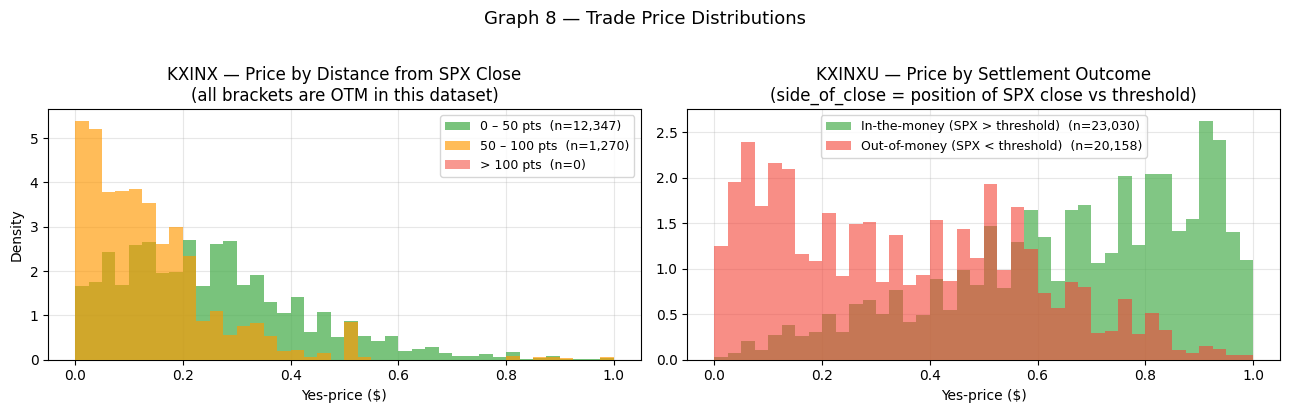

In [40]:
# ── KXINX: per-trade distance bucket ────────────────────────────────────────
kxinx_dist = (
    kxinx
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap"))
          .alias("distance")
    )
    .with_columns(
        pl.when(pl.col("distance") <= 50 ).then(pl.lit("0 – 50 pts"))
          .when(pl.col("distance") <= 100).then(pl.lit("50 – 100 pts"))
          .otherwise(pl.lit("> 100 pts"))
          .alias("dist_bucket")
    )
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: KXINX by distance bucket
ax = axes[0]
bucket_styles = {
    "0 – 50 pts":   ("#4CAF50", 0.75),
    "50 – 100 pts": ("#FF9800", 0.65),
    "> 100 pts":    ("#F44336", 0.55),
}
for bucket, (color, alpha) in bucket_styles.items():
    prices = kxinx_dist.filter(pl.col("dist_bucket") == bucket)["price"].to_numpy()
    ax.hist(prices, bins=40, range=(0, 1), color=color, alpha=alpha,
            density=True, label=f"{bucket}  (n={len(prices):,})", zorder=3)
ax.set_xlabel("Yes-price ($)")
ax.set_ylabel("Density")
ax.set_title("KXINX — Price by Distance from SPX Close\n(all brackets are OTM in this dataset)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: KXINXU — side_of_close directly encodes the settlement outcome
ax = axes[1]
# "below" → threshold below final close → YES (above threshold) wins → ITM
# "above" → threshold above final close → YES loses → OTM
for label, soc, color, alpha in [
    ("In-the-money (SPX > threshold)",  "below", "#4CAF50", 0.70),
    ("Out-of-money (SPX < threshold)",  "above", "#F44336", 0.60),
]:
    prices = kxinxu.filter(pl.col("side_of_close") == soc)["price"].to_numpy()
    ax.hist(prices, bins=40, range=(0, 1), color=color, alpha=alpha,
            density=True, label=f"{label}  (n={len(prices):,})", zorder=3)
ax.set_xlabel("Yes-price ($)")
ax.set_title("KXINXU — Price by Settlement Outcome\n(side_of_close = position of SPX close vs threshold)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Graph 8 — Trade Price Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3.4: Graph 9: Intraday KXINX price convergence on the Most Active Trading Day

On each day, all KXINX brackets start the session at some price reflecting the probability the market assigns to SPX closing in that range.  As the session progresses the prices of brackets near the final close should converge toward $1, while all others should converge toward $0.

Note: Note: the winning (ATM) bracket is absent from this data export. We show the 5 available brackets nearest to the SPX close.

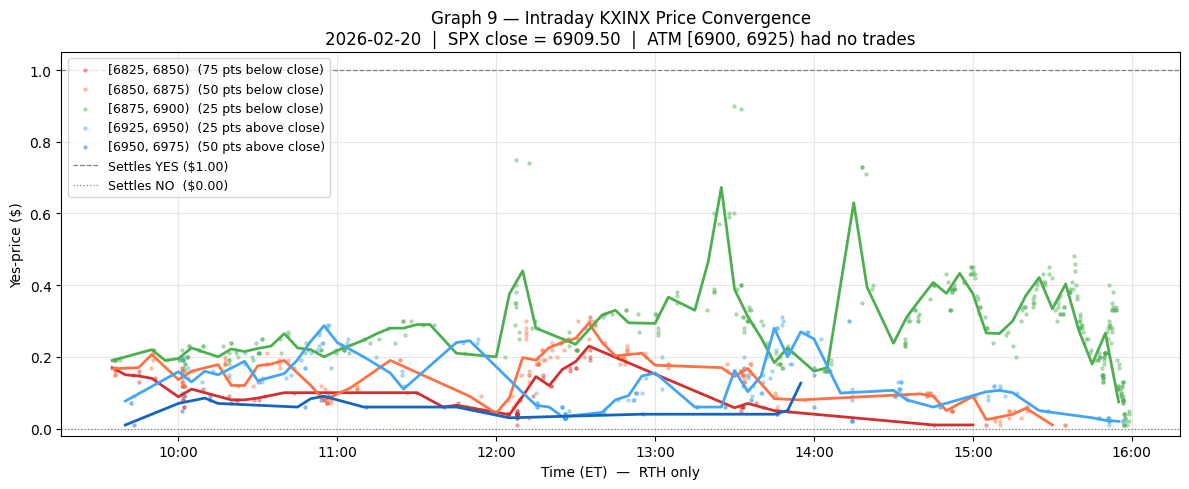

In [41]:
busiest_date = (
    kxinx.group_by("date")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(1)["date"]
    .item()
)
spx_close_val = (
    spx_close_daily
    .filter(pl.col("date") == busiest_date)["spx_close"]
    .item()
)

# ── Filter to RTH on the settlement date ────────────────────────────────────
day_rth = (
    kxinx
    .filter(pl.col("date") == busiest_date)
    .filter(
        (pl.col("ts").dt.hour() > 9) |
        ((pl.col("ts").dt.hour() == 9) & (pl.col("ts").dt.minute() >= 30))
    )
    .filter(pl.col("ts").dt.hour() < 16)
    .select(["ts", "bracket_floor", "bracket_cap", "price"])
    .sort("ts")
)

# ── Pick the 5 available brackets closest to ATM ────────────────────────────
atm_floor    = float((int(spx_close_val) // 25) * 25)
all_floors   = sorted(day_rth["bracket_floor"].unique().to_list())
target_floors = sorted(sorted(all_floors, key=lambda f: abs(f - atm_floor))[:5])

day_pd = (
    day_rth
    .filter(pl.col("bracket_floor").is_in(target_floors))
    .to_pandas()
)
# Strip timezone so matplotlib renders ET wall-clock times (not UTC)
day_pd["ts"] = pd.to_datetime(day_pd["ts"]).dt.tz_localize(None)

# ── Plot ──────────────────────────────────────────────────────────────────────
palette   = ["#d32f2f", "#ff7043", "#4CAF50", "#42a5f5", "#1565c0"]
color_map = {f: c for f, c in zip(target_floors, palette)}

fig, ax = plt.subplots(figsize=(12, 5))

for floor in target_floors:
    sub = day_pd[day_pd["bracket_floor"] == floor].sort_values("ts")
    if sub.empty:
        continue
    c         = color_map[floor]
    dist      = abs(floor - atm_floor)
    direction = "above" if floor >= atm_floor else "below"
    label     = f"[{floor:.0f}, {floor+25:.0f})  ({dist:.0f} pts {direction} close)"

    ax.scatter(sub["ts"], sub["price"], s=5, alpha=0.35, color=c, label=label)
    roll = sub.set_index("ts")["price"].resample("5min").mean().dropna()
    ax.plot(roll.index, roll.values, lw=2, color=c)

ax.axhline(1.0, color="gray", ls="--", lw=0.9, label="Settles YES ($1.00)")
ax.axhline(0.0, color="gray", ls=":",  lw=0.9, label="Settles NO  ($0.00)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.set_xlabel("Time (ET)  —  RTH only")
ax.set_ylabel("Yes-price ($)")
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    f"Graph 9 — Intraday KXINX Price Convergence\n"
    f"{busiest_date}  |  SPX close = {spx_close_val:.2f}  "
    f"|  ATM [{atm_floor:.0f}, {atm_floor+25:.0f}) had no trades"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3.5: Graph 10: Contract VWAP vs Distance from SPX Close (Implied Probability Curve)

For OTM contracts, VWAP should fall as the contract moves further from the money.


KXINX:  all contracts in this dataset are OTM (bracket fully above or below close). distance_from_close = pts from nearest bracket edge to SPX close.

KXINXU: only OTM contracts are shown (side_of_close == "above" means SPX closed ABOVE the threshold → YES (above) contract is OTM; distance = threshold − close). Mixing ITM and OTM would flatten the curve, so we filter to OTM only.

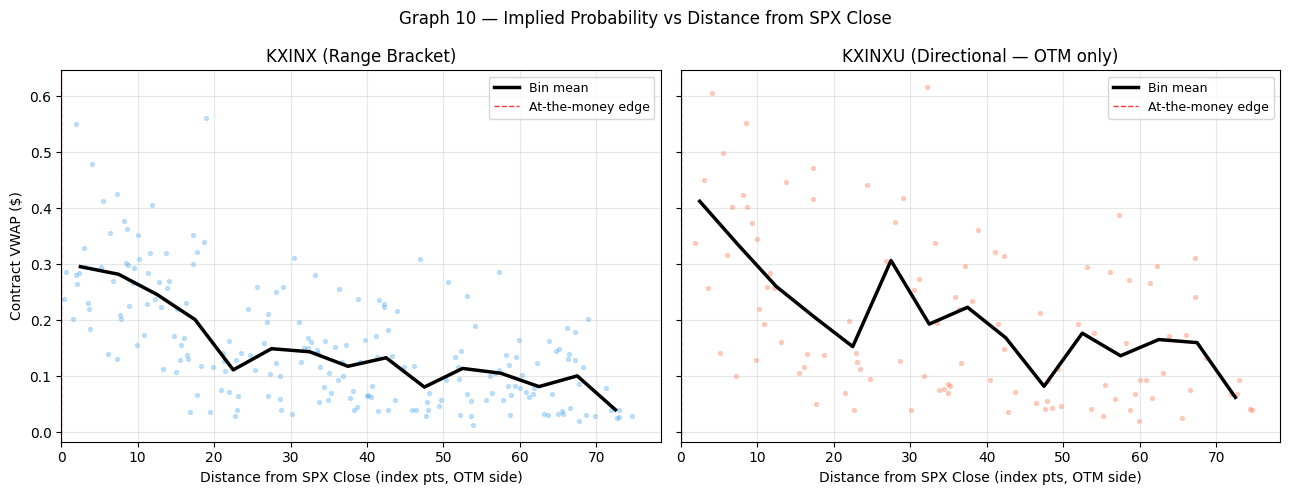

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, vwap_df, title, color, otm_filter in [
    (axes[0], kxinx_vwap,  "KXINX (Range Bracket)", "#2196F3",
     pl.col("distance_from_close").is_not_null() & (pl.col("distance_from_close") >= 0)),
    (axes[1], kxinxu_vwap, "KXINXU (Directional — OTM only)", "#FF5722",
     (pl.col("side_of_close") == "above") &
     pl.col("distance_from_close").is_not_null() &
     (pl.col("distance_from_close") >= 0)),
]:
    df = vwap_df.filter(otm_filter & pl.col("vwap").is_not_null()).to_pandas()

    ax.scatter(df["distance_from_close"], df["vwap"],
               s=8, alpha=0.25, color=color, rasterized=True)

    # Bin-mean overlay in 5-pt buckets
    bin_edges  = np.arange(0, 201, 5)
    bin_labels = np.arange(2.5, 200, 5)
    df["dist_bin"] = pd.cut(df["distance_from_close"], bins=bin_edges, labels=bin_labels)
    binned = (
        df.groupby("dist_bin", observed=True)["vwap"]
        .mean().reset_index()
        .assign(dist_bin=lambda d: d["dist_bin"].astype(float))
        .dropna().sort_values("dist_bin")
    )
    ax.plot(binned["dist_bin"], binned["vwap"],
            color="black", lw=2.5, label="Bin mean")

    ax.axvline(0, color="red", ls="--", lw=1, alpha=0.8, label="At-the-money edge")
    ax.set_xlabel("Distance from SPX Close (index pts, OTM side)")
    ax.set_title(f"{title}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)

axes[0].set_ylabel("Contract VWAP ($)")
plt.suptitle("Graph 10 — Implied Probability vs Distance from SPX Close", fontsize=12)
plt.tight_layout()
plt.show()


In [52]:
import polars as pl

sim_df = pl.read_parquet("simulation_output.parquet")

In [53]:
sim_df

ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,period_return,cumulative_return,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-01-01 19:19:38 EST,"""KXINX-26JAN02H1600-B6912""",6888.14,14.71,685.81,null,0.4,0,1,0.176994,0.15,0.2,50,50,false,true,10000.0,0.0,0.0,0.0,0,0,10000.0,0,0
2026-01-01 19:27:03 EST,"""KXINX-26JAN02H1600-B6887""",6888.14,14.71,685.81,null,0.5,0,98,0.201064,0.18,0.22,50,50,false,true,10000.02261,0.02261,0.000002,0.000002,0,0,10000.2,0,-1
2026-01-01 19:27:55 EST,"""KXINX-26JAN02H1600-B6787""",6888.14,14.71,685.81,null,0.41,0,15,0.025441,0.0,0.05,50,50,false,true,10000.9659,0.9659,0.000094,0.000097,0,0,10011.2,1,-51
2026-01-01 19:49:43 EST,"""KXINXU-26JAN02H1600-T6924.9999""",6888.14,14.71,685.81,null,0.1,0,48,0.223746,0.2,0.25,50,50,false,false,10001.25548,1.25548,0.000029,0.000126,0,4,7268.71,0,-66
2026-01-01 20:13:30 EST,"""KXINX-26JAN02H1600-B6912""",6888.14,14.71,685.81,null,0.42,0,21,0.179925,0.16,0.2,51,49,false,true,10001.166926,1.166926,-0.000009,0.000117,-1,4,7268.71,0,-66
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,0.999999,0.88,1.0,0,2,false,false,10856.705844,856.705844,-0.000064,0.085671,98,-137,105329.505,0,320
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,0.999999,0.88,1.0,0,2,false,false,10856.343003,856.343003,-0.000033,0.085634,98,-137,105329.505,0,320
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,0.999999,0.88,1.0,0,2,false,false,10851.934657,851.934657,-0.000406,0.085193,98,-137,105329.505,1,320


In [54]:
# Report the number of trades for Kalshi contracts & SPY contracts

# We'll count kalshi contract trades and spy contract trades based on sim_df columns

# Kalshi contract trades: Count rows where 'contract_id' is not null
num_kalshi_trades = sim_df.filter(pl.col('contract_id').is_not_null()).height

# SPY contract trades: Count rows where 'pos_spy' changes (i.e., delta(pos_spy) != 0)
# We need at least 2 rows for a diff to exist
spy_pos = sim_df.select("pos_spy").to_series()
num_spy_trades = 0
if len(spy_pos) > 1:
    num_spy_trades = (spy_pos.diff().fill_null(0) != 0).sum()

print(f"Number of Kalshi contract trades: {num_kalshi_trades}")
print(f"Number of SPY contract trades: {num_spy_trades}")

Number of Kalshi contract trades: 44363
Number of SPY contract trades: 19153


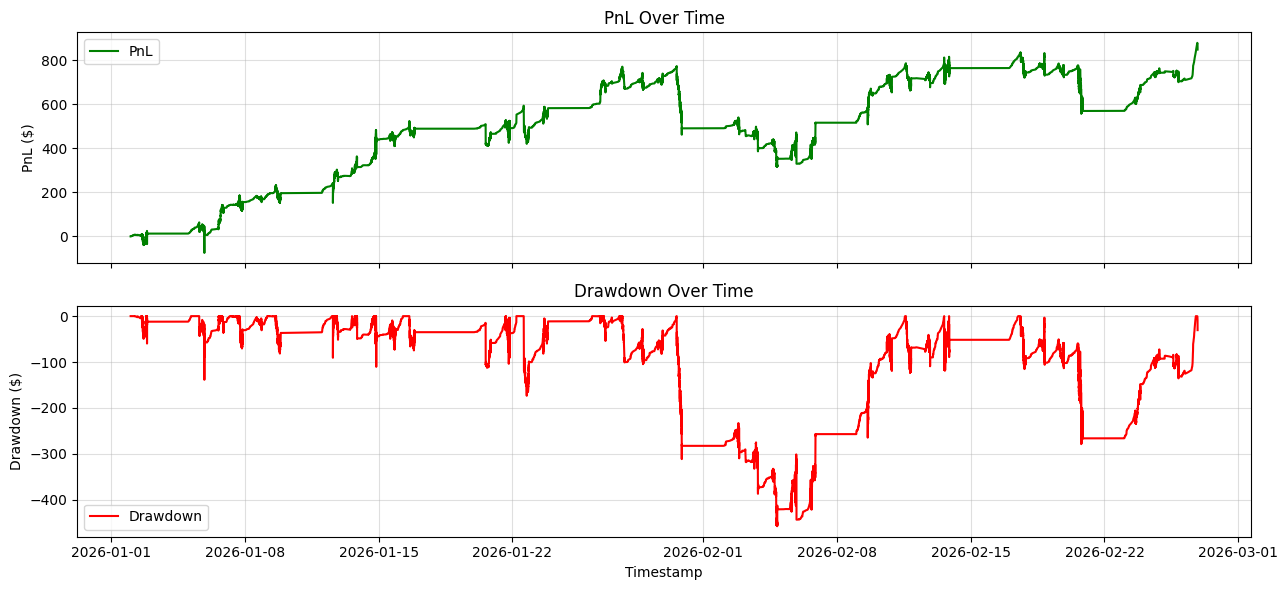

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate pnl from 'pnl' column
if "pnl" in sim_df.columns:
    pnl = sim_df["pnl"].to_numpy()
else:
    pnl = np.zeros(sim_df.height)

# Calculate running peak for drawdown
running_max = np.maximum.accumulate(pnl)
drawdown = pnl - running_max

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax[0].plot(sim_df["ts"].to_numpy(), pnl, label="PnL", color="green")
ax[0].set_ylabel("PnL ($)")
ax[0].set_title("PnL Over Time")
ax[0].grid(alpha=0.4)
ax[0].legend()

ax[1].plot(sim_df["ts"].to_numpy(), drawdown, label="Drawdown", color="red")
ax[1].set_ylabel("Drawdown ($)")
ax[1].set_title("Drawdown Over Time")
ax[1].grid(alpha=0.4)
ax[1].legend()

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [57]:
import numpy as np

# Compute mean, volatility (standard deviation), and Sharpe ratio of PnL
# Assume zero risk-free rate for Sharpe calculation

if "pnl" in sim_df.columns:
    pnl = sim_df["pnl"].to_numpy()
else:
    pnl = np.zeros(sim_df.height)

mean_pnl = np.mean(pnl)
volatility_pnl = np.std(pnl)
sharpe = mean_pnl / volatility_pnl if volatility_pnl != 0 else np.nan

print(f"Mean PnL: {mean_pnl:.2f}")
print(f"PnL Volatility: {volatility_pnl:.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")


Mean PnL: 520.44
PnL Volatility: 233.08
Sharpe Ratio: 2.23
